<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Sharpe%2C%20William%20F.%20(1964)%20Capital%20Asset%20Prices%20A%20Theory%20of%20Market%20Equilibrium%20under%20Conditions%20of%20Risk/Market_Equilibrium_under_Conditions_of_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ============================================
# Capital Asset Pricing Model (CAPM) for two stocks
# ============================================

# Install dependencies (if needed)
!pip install yfinance pandas numpy matplotlib seaborn statsmodels

# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.style.use('seaborn-v0_8')

# ============================================
# 1. Download Market & Asset Data
# ============================================

# Choose assets
assets = ["CVX", "FCX"]   # Chevron and Freeport-McMoRan
market = "^GSPC"           # S&P 500 index

start_date = "2018-01-01"
end_date = "2024-01-01"

# Download asset data
asset_data = yf.download(assets, start=start_date, end=end_date, auto_adjust=True)['Close']
market_data = yf.download(market, start=start_date, end=end_date, auto_adjust=True)['Close']

# Combine into one DataFrame
data = asset_data.copy()
data['Market'] = market_data
data.dropna(inplace=True)

data.head()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


Ticker,CVX,FCX,Market
Date,,,
2018-01-02,89.452377,17.888090,2695.810059
2018-01-03,90.104439,17.616644,2713.060059
2018-01-04,89.823967,17.860941,2723.989990
2018-01-05,89.676743,18.005714,2743.149902
2018-01-08,90.118462,17.924276,2747.709961


In [10]:
# ============================================
# 2. Compute Returns
# ============================================

returns = data.pct_change().dropna()

returns.head()

Ticker,CVX,FCX,Market
Date,,,
2018-01-03,0.007289,-0.015175,0.006399
2018-01-04,-0.003113,0.013867,0.004029
2018-01-05,-0.001639,0.008106,0.007034
2018-01-08,0.004926,-0.004523,0.001662
2018-01-09,-0.005368,-0.044927,0.001303


CAPM is based on returns, not prices, so this block converts price data into percentage changes over time. By calculating daily returns, we transform the raw data into a form that reflects gains and losses experienced by investors. This is essential because the model analyzes how an asset’s returns move in relation to market returns, rather than their absolute price levels.

In [11]:
# ============================================
# 3. Estimate Beta (β) for multiple assets
# CAPM Core Idea: E(R_i) = R_f + β_i (E(R_m) - R_f)
# ============================================

for asset in assets:
    # Define dependent and independent variables
    X = sm.add_constant(returns['Market'])  # Add constant for alpha
    y = returns[asset]

    # Run regression
    model = sm.OLS(y, X).fit()

    # Extract beta and alpha
    beta = model.params['Market']
    alpha = model.params['const']

    # Print results
    print(f"CAPM Regression for {asset}")
    print(model.summary())
    print(f"Beta: {beta:.4f}")
    print(f"Alpha: {alpha:.4f}\n")

CAPM Regression for CVX
                            OLS Regression Results                            
Dep. Variable:                    CVX   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     921.3
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          2.67e-158
Time:                        23:22:55   Log-Likelihood:                 4022.7
No. Observations:                1508   AIC:                            -8041.
Df Residuals:                    1506   BIC:                            -8031.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.608e-05      0

This block is the core empirical implementation of CAPM. It uses linear regression to estimate the asset’s beta (β), which measures how sensitive the asset is to movements in the overall market. In the regression, market returns are the independent variable and asset returns are the dependent variable. The slope of the regression line is beta, representing systematic risk, while the intercept (alpha) indicates whether the asset outperforms or underperforms what CAPM predicts. According to Sharpe’s theory, beta is the only type of risk that should be rewarded in equilibrium.

In [12]:
# ============================================
# 4. Expected Return via CAPM for multiple assets
# ============================================

risk_free_rate = 0.02  # 2% annual risk-free rate
market_return = returns['Market'].mean() * 252  # annualized market return

print(f"Expected Market Return (annualized): {market_return:.4f}\n")

# Loop over assets to calculate expected return
for asset in assets:
    # Run regression to get beta
    X = sm.add_constant(returns['Market'])
    y = returns[asset]
    model = sm.OLS(y, X).fit()
    beta = model.params['Market']

    # Expected return via CAPM
    expected_return = risk_free_rate + beta * (market_return - risk_free_rate)

    print(f"{asset} - Beta: {beta:.4f}")
    print(f"{asset} - Expected CAPM Return: {expected_return:.4f}\n")

Expected Market Return (annualized): 0.1168

CVX - Beta: 1.0093
CVX - Expected CAPM Return: 0.1177

FCX - Beta: 1.5373
FCX - Expected CAPM Return: 0.1689



Here, the theoretical CAPM equation is applied using the estimated beta. A risk-free rate is specified (as a baseline return with no risk), and the average market return is calculated and annualized. The model then computes the asset’s expected return based on its exposure to market risk. This step directly implements Sharpe’s key equation, which states that expected return is a linear function of beta.

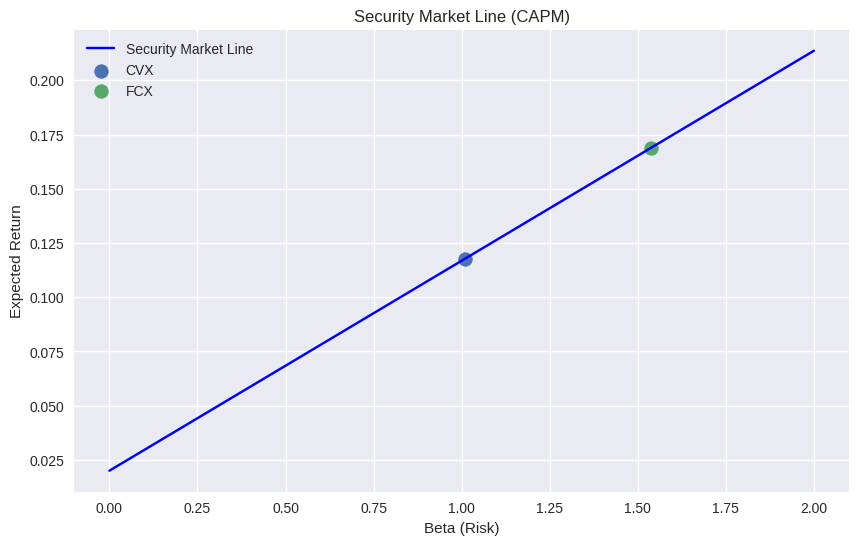

In [13]:
# ============================================
# 5. Security Market Line (SML) for multiple assets
# ============================================

# Generate SML line
betas_range = np.linspace(0, 2, 100)
sml = risk_free_rate + betas_range * (market_return - risk_free_rate)

plt.figure(figsize=(10,6))
plt.plot(betas_range, sml, label='Security Market Line', color='blue')

# Plot each asset on the SML
for asset in assets:
    # Run regression to get beta
    X = sm.add_constant(returns['Market'])
    y = returns[asset]
    model = sm.OLS(y, X).fit()
    beta = model.params['Market']

    # CAPM expected return
    expected_return = risk_free_rate + beta * (market_return - risk_free_rate)

    # Plot point
    plt.scatter(beta, expected_return, label=f'{asset}', s=100)

plt.xlabel("Beta (Risk)")
plt.ylabel("Expected Return")
plt.title("Security Market Line (CAPM)")
plt.legend()
plt.grid(True)
plt.show()

This block visualizes the CAPM relationship by plotting the Security Market Line, which shows expected return as a function of beta. The line represents equilibrium pricing: all correctly priced assets should lie on it. The chosen asset is plotted as a point, allowing you to see whether it appears overvalued or undervalued relative to the model. This visualization captures one of the central insights of the CAPM—that risk and return are linearly related across all assets.

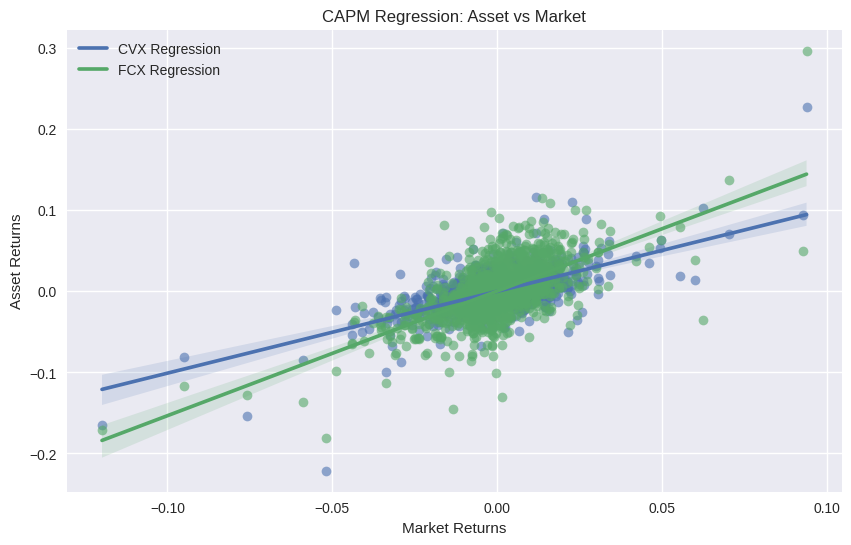

In [14]:
# ============================================
# 6. Visualization of Regression for multiple assets
# ============================================

plt.figure(figsize=(10,6))

for asset in assets:
    sns.regplot(
        x=returns['Market'],
        y=returns[asset],
        line_kws={"label": f"{asset} Regression"},
        scatter_kws={"alpha":0.6}
    )

plt.xlabel("Market Returns")
plt.ylabel("Asset Returns")
plt.title("CAPM Regression: Asset vs Market")
plt.legend()
plt.grid(True)
plt.show()

This graph shows the relationship between each stock’s daily returns (CVX and FCX) and the market’s returns. The regression lines represent CAPM beta (slope) and alpha (intercept), illustrating how sensitive each stock is to market movements and any excess return independent of the market. By overlaying both lines, it’s easy to compare volatility, alignment with the market, and potential outperformance. A tighter clustering of points around the line indicates that market risk explains most of the stock’s behavior, reinforcing the CAPM idea that systematic risk is the primary driver of returns.
